# Convolutional Neural Network (on Mel Spectograms):

In this version of ResoNET we take the Short-Time Fourier Transform (STFT) which segments the audio into time frames and for each timeframe it calculates it's frequency components. Hence as a result we get Spectograms which on one axis represents the time and on the other axis represents the frequency. We train a CNN (As spectograms are 2d images) to predict the class of the test audio by converting it into Spectogram and then feeding it into the model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Installing the necessary libraries: `librosa` for audio processing and `torchaudio` for PyTorch audio utilities. Also importing `glob` to help find the audio files and `tqdm` for progress bars during training.

In [2]:
!pip install librosa torchaudio

import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Set device for GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Audio Preprocessing Pipeline
This section defines the core function used to transform raw audio files into a format suitable for a Deep Learning model. Specifically, we load the audio, resample it to a consistent sample rate, trim or pad it to a fixed length, and finally compute a normalized Log-Mel Spectrogram.

Defining the preprocessing pipeline. This function will load an audio file, resample it to 16,000 Hz, trim/pad it to a fixed duration of 3 seconds, and then convert it into a Log-Mel Spectrogram with 64 Mel bands.

In [14]:
def load_audio_and_create_spectrogram(audio_path, sr=16000, duration=3, n_mels=64, plot=False):
    # Load audio
    audio, current_sr = librosa.load(audio_path, sr=None)

    # Resample if necessary
    if current_sr != sr:
        audio = librosa.resample(audio, orig_sr=current_sr, target_sr=sr)

    # Trim/Pad audio to a fixed duration
    target_length = int(sr * duration)
    if len(audio) > target_length:
        audio = audio[:target_length]
    else:
        audio = np.pad(audio, (0, max(0, target_length - len(audio))), "constant")

    # Convert to Mel Spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

    # Convert to Log-Mel Spectrogram
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Normalize to [0, 1]
    min_val = log_mel_spectrogram.min()
    max_val = log_mel_spectrogram.max()
    log_mel_spectrogram = (log_mel_spectrogram - min_val) / (max_val - min_val)

    if plot:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(log_mel_spectrogram, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Log-Mel Spectrogram: {os.path.basename(audio_path)}')
        plt.tight_layout()
        plt.show()

    return torch.tensor(log_mel_spectrogram).float().unsqueeze(0)

Displaying spectrogram for: /content/drive/My Drive/ResoNET dataset/FSD50K.dev_audio_16k/26834.wav


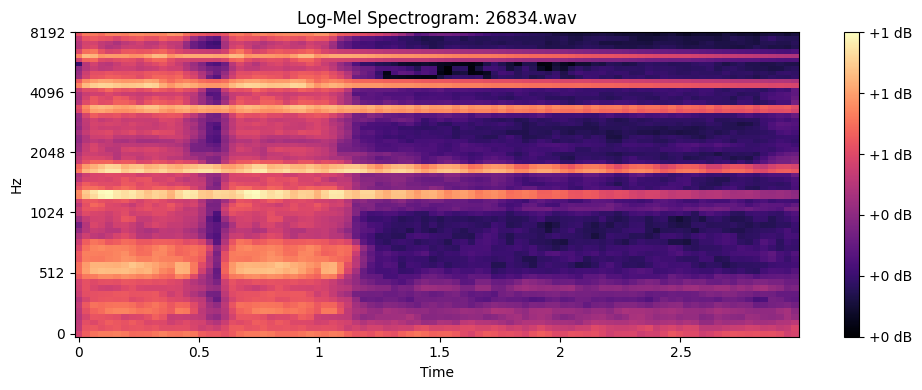

In [17]:
import random

if 'audio_paths' in globals() and len(audio_paths) > 0:
    # Pick a random audio path from the training list
    random_path = random.choice(audio_paths)
    print(f"Displaying spectrogram for: {random_path}")

    # Generate and plot the spectrogram using the updated function
    example_spec = load_audio_and_create_spectrogram(random_path, plot=True)
else:
    print("Audio paths not found.")

### 2. Custom PyTorch Dataset
To efficiently handle thousands of audio files without exhausting system memory (RAM), we define an `AudioDataset` class. This class loads and processes each audio file on-spot only when it is needed during training.

Next creating a custom `AudioDataset` class. This class will handle loading the audio files and applying the preprocessing function on-spot when an item is requested. This prevents loading all audio into RAM at once.

In [5]:
class AudioDataset(Dataset):
    def __init__(self, audio_paths, labels, sr=16000, duration=3, n_mels=64):
        self.audio_paths = audio_paths
        self.labels = labels
        self.sr = sr
        self.duration = duration
        self.n_mels = n_mels
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(list(set(labels))))}

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label_name = self.labels[idx]
        label_idx = self.label_to_idx[label_name]

        spectrogram = load_audio_and_create_spectrogram(audio_path, self.sr, self.duration, self.n_mels)

        return spectrogram, torch.tensor(label_idx, dtype=torch.long)

### 3. CNN Model Architecture
Defining a Convolutional Neural Network (CNN) for the Spectograms. The model uses layers of convolutions to extract patterns, followed by Global Average Pooling to reduce complexity before the final classification.

Now defining `SimpleAudioCNN` architecture. It will consist of 4 convolutional layers, each followed by Batch Normalization and ReLU activation, then a Global Average Pooling layer, and finally a Linear layer for classification.

In [12]:
class SimpleAudioCNN(nn.Module):
    def __init__(self, num_classes, input_channels=1):
        super(SimpleAudioCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # Layer 1
            nn.Conv2d(input_channels, 32, kernel_size=(3, 3), padding=1),
            # Input: (batch_size, 1, n_mels, time_frames)
            # Output after Conv2d: (batch_size, 32, n_mels, time_frames)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            # Output after MaxPool2d: (batch_size, 32, n_mels/2, time_frames/2)

            # Layer 2
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            # Input: (batch_size, 32, n_mels/2, time_frames/2)
            # Output after Conv2d: (batch_size, 64, n_mels/2, time_frames/2)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            # Output after MaxPool2d: (batch_size, 64, n_mels/4, time_frames/4)

            # Layer 3
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            # Input: (batch_size, 64, n_mels/4, time_frames/4)
            # Output after Conv2d: (batch_size, 128, n_mels/4, time_frames/4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            # Output after MaxPool2d: (batch_size, 128, n_mels/8, time_frames/8)

            # Layer 4 (optional, depending on desired depth)
            nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1),
            # Input: (batch_size, 128, n_mels/8, time_frames/8)
            # Output after Conv2d: (batch_size, 256, n_mels/8, time_frames/8)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            # Output after MaxPool2d: (batch_size, 256, n_mels/16, time_frames/16)
        )

        # Global Average Pooling layer
        # This will reduce (batch_size, channels, height, width) to (batch_size, channels)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Final classification layer
        # The input features to the linear layer will be the number of output channels from the last conv layer
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 1, n_mels, time_frames)
        x = self.conv_layers(x)
        # x shape after conv_layers (with 4 layers): (batch_size, 256, n_mels/16, time_frames/16)

        x = self.global_avg_pool(x)
        # x shape after global_avg_pool: (batch_size, 256, 1, 1)

        x = x.view(x.size(0), -1) # Flatten the tensor
        # x shape after flattening: (batch_size, 256)

        x = self.fc(x)
        # x shape after fc: (batch_size, num_classes)
        return x

### 4. Data Discovery and Label Mapping
This block scans the Google Drive directories for `.wav` files and synchronizes them with the labels provided in the CSV metadata files. It also separates the evaluation set into a final test group.

In [7]:
# Define the base directory
base_data_path = "/content/drive/My Drive/ResoNET dataset"

# Map CSV files to their respective audio subfolders
# separating the eval folder for testing
train_csv_to_folder = {
    "Cleaned_ESC50.csv": "ESC50_16000",
    "FSD50K_dev_cleaned.csv": "FSD50K.dev_audio_16k"
}
test_csv_to_folder = {
    "FSDK50_eval_cleaned.csv": "FSD50K.eval_audio_16k"
}

audio_paths, labels = [], []
test_audio_paths, test_labels = [], []

def process_csvs(mapping, paths_list, labels_list):
    for csv_file, sub_folder in mapping.items():
        csv_path = os.path.join(base_data_path, csv_file)
        folder_path = os.path.join(base_data_path, sub_folder)
        if os.path.exists(csv_path) and os.path.exists(folder_path):
            print(f"Processing {csv_file}...")
            df = pd.read_csv(csv_path)
            file_col = 'fname' if 'fname' in df.columns else df.columns[0]
            label_col = 'labels' if 'labels' in df.columns else df.columns[1]
            folder_files = {f: os.path.join(root, f) for root, _, files in os.walk(folder_path) for f in files}
            for _, row in df.iterrows():
                fname = str(row[file_col])
                if not fname.lower().endswith('.wav'): fname += '.wav'
                if fname in folder_files:
                    paths_list.append(folder_files[fname])
                    labels_list.append(row[label_col])

print("--- Loading Training/Validation Data ---")
process_csvs(train_csv_to_folder, audio_paths, labels)
print("\n--- Loading Test Data ---")
process_csvs(test_csv_to_folder, test_audio_paths, test_labels)

if not audio_paths or not test_audio_paths:
    print("Error: Missing data in one of the sets.")
else:
    all_labels = sorted(list(set(labels + test_labels)))
    num_classes = len(all_labels)
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
    idx_to_label = {idx: label for label, idx in label_to_idx.items()}
    print(f"\nTraining/Val: {len(audio_paths)} files, Test: {len(test_audio_paths)} files.")
    print(f"Total unique classes: {num_classes}")

--- Loading Training/Validation Data ---
Processing Cleaned_ESC50.csv...
Processing FSD50K_dev_cleaned.csv...

--- Loading Test Data ---
Processing FSDK50_eval_cleaned.csv...

Training/Val: 2453 files, Test: 1004 files.
Total unique classes: 7


### 5. Training and Validation Logic
Here we implement the training loop. It includes tracking loss and accuracy for both training and validation sets. We've also included **Early Stopping** to stop training automatically if the validation loss stops improving.

Defining the training and evaluation functions. This includes the loss function (CrossEntropyLoss), optimizer (Adam), and accuracy calculation. It also moves the data and model to the GPU if available.

In [8]:
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, patience=3):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct_train / total_train

        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_acc = 100 * correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

        # Early Stopping & Best Model Saving
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
            print("Validation loss improved, saving model weights.")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    model.load_state_dict(best_model_wts)
    return train_losses, val_losses, train_accuracies, val_accuracies

### 6. Performance Visualization
This utility function creates plots for Loss and Accuracy, allowing us to diagnose if the model is learning correctly or if it is starting to overfit.

After training, we will plot the loss and accuracy curves to visualize the model's performance over epochs.

In [9]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'o-', label='Training Loss')
    plt.plot(epochs, val_losses, 'o-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'o-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'o-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### 7. Execution: Training and Testing
This is the final execution block where we initialize the data loaders, create the model instance, start the training process, and perform a final accuracy check on the unseen test data.

Starting training...


Epoch 1/15 Training:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch 1/15 Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/15, Train Loss: 0.9044, Train Acc: 66.72%, Val Loss: 0.8753, Val Acc: 63.34%
Validation loss improved, saving model weights.


Epoch 2/15 Training:   0%|          | 0/62 [00:00<?, ?it/s]

...

Epoch 8/15 Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 8/15, Train Loss: 0.4057, Train Acc: 83.74%, Val Loss: 0.4910, Val Acc: 80.86%


Epoch 9/15 Training:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch 9/15 Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9/15, Train Loss: 0.3733, Train Acc: 85.22%, Val Loss: 0.5710, Val Acc: 76.78%
Early stopping triggered after 9 epochs.


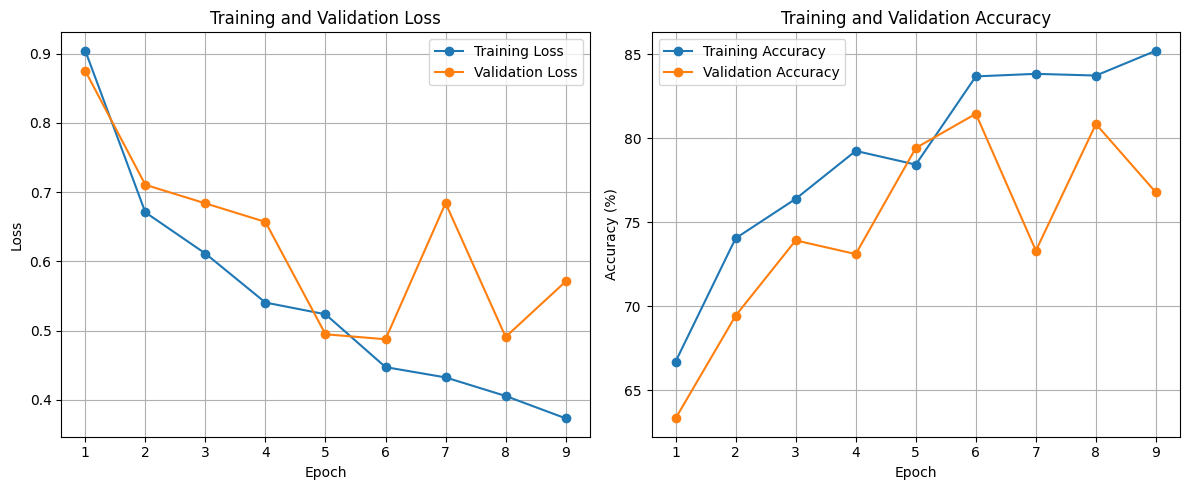


--- Starting Inference on Test Set ---


Testing Inference:   0%|          | 0/32 [00:00<?, ?it/s]


Final Test Accuracy: 73.41%
Sample Inference: Actual: Doorbell | Predicted: Doorbell


In [13]:
if __name__ == '__main__':
    if not audio_paths:
        print("No training data found.")
    else:
        # 1. Setup Data
        dataset = AudioDataset(audio_paths, labels)
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

        # 2. Train Model
        model = SimpleAudioCNN(num_classes=num_classes).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        print("Starting training...")
        t_losses, v_losses, t_accs, v_accs = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15)
        plot_metrics(t_losses, v_losses, t_accs, v_accs)

        # 3. Final Inference on Test Set
        print("\n--- Starting Inference on Test Set ---")
        test_dataset = AudioDataset(test_audio_paths, test_labels)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, targets in tqdm(test_loader, desc="Testing Inference"):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total_test += targets.size(0)
                correct_test += (predicted == targets).sum().item()

        test_accuracy = 100 * correct_test / total_test
        print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")

        # Show sample inference
        sample_input, sample_label = test_dataset[0]
        sample_input = sample_input.unsqueeze(0).to(device)
        output = model(sample_input)
        prediction = idx_to_label[torch.argmax(output).item()]
        print(f"Sample Inference: Actual: {test_labels[0]} | Predicted: {prediction}")